In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
# 样本数量
n_samples = 300

# 两个输入特征 x1, x2
X = torch.rand(n_samples, 2) * 10

# 真实规律：y = 3*x1 - 2*x2 + 5 + noise
noise = torch.randn(n_samples, 1) * 2
y = 3 * X[:, 0:1] - 2 * X[:, 1:2] + 5 + noise

print("X shape:", X.shape)
print("y shape:", y.shape)

print(X[:5])
print(y[:5])

X shape: torch.Size([300, 2])
y shape: torch.Size([300, 1])
tensor([[8.8227, 9.1500],
        [3.8286, 9.5931],
        [3.9045, 6.0090],
        [2.5657, 7.9364],
        [9.4077, 1.3319]])
tensor([[14.2196],
        [ 0.6654],
        [ 4.8890],
        [-2.6615],
        [31.5050]])


In [3]:
# 打乱索引
indices = torch.randperm(n_samples)

train_size = int(0.8 * n_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([240, 2])
y_train: torch.Size([240, 1])
X_test: torch.Size([60, 2])
y_test: torch.Size([60, 1])


In [4]:
X_mean = X_train.mean(dim=0, keepdim=True)
X_std = X_train.std(dim=0, keepdim=True)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("标准化前：")
print(X_train[:5])

print("标准化后：")
print(X_train_scaled[:5])

标准化前：
tensor([[8.9130, 1.4474],
        [2.5331, 2.6358],
        [8.8227, 9.1500],
        [9.0208, 5.8111],
        [8.9181, 1.1823]])
标准化后：
tensor([[ 1.3662, -1.0446],
        [-0.8935, -0.6404],
        [ 1.3342,  1.5754],
        [ 1.4044,  0.4397],
        [ 1.3680, -1.1348]])


In [5]:
class MLPRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.model(x)

In [6]:
model = MLPRegressor()

print(model)

MLPRegressor(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [7]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
epochs = 300

train_losses = []

for epoch in range(epochs):
    # 1. 前向传播
    y_pred = model(X_train_scaled)
    
    # 2. 计算损失
    loss = loss_fn(y_pred, y_train)
    
    # 3. 梯度清零
    optimizer.zero_grad()
    
    # 4. 反向传播
    loss.backward()
    
    # 5. 更新参数
    optimizer.step()
    
    # 记录 loss
    train_losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 109.9667
Epoch [100/300], Loss: 4.6016
Epoch [150/300], Loss: 3.8285
Epoch [200/300], Loss: 3.6402
Epoch [250/300], Loss: 3.5833
Epoch [300/300], Loss: 3.5596


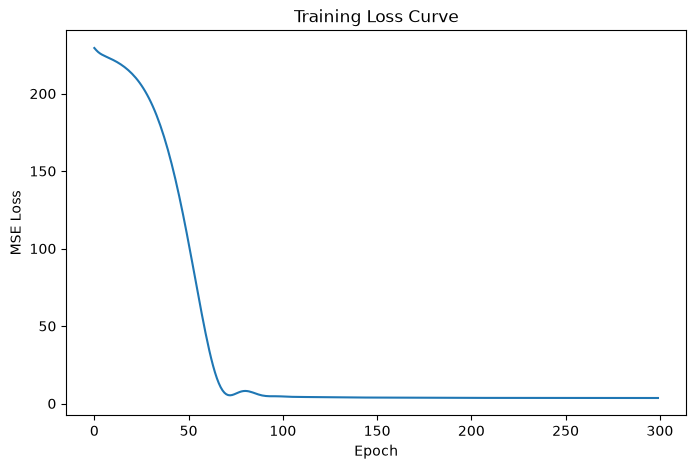

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()

In [10]:
model.eval()

with torch.no_grad():
    y_test_pred = model(X_test_scaled)
    test_loss = loss_fn(y_test_pred, y_test)

print("Test MSE:", test_loss.item())

Test MSE: 3.831976890563965


In [11]:
for i in range(10):
    print(f"真实值: {y_test[i].item():.2f}, 预测值: {y_test_pred[i].item():.2f}")

真实值: 19.86, 预测值: 19.73
真实值: 5.41, 预测值: 2.72
真实值: 19.30, 预测值: 19.20
真实值: -9.38, 预测值: -8.88
真实值: 9.87, 预测值: 6.86
真实值: 27.65, 预测值: 26.61
真实值: 17.41, 预测值: 18.70
真实值: 19.48, 预测值: 17.71
真实值: 32.74, 预测值: 29.58
真实值: 32.67, 预测值: 29.56


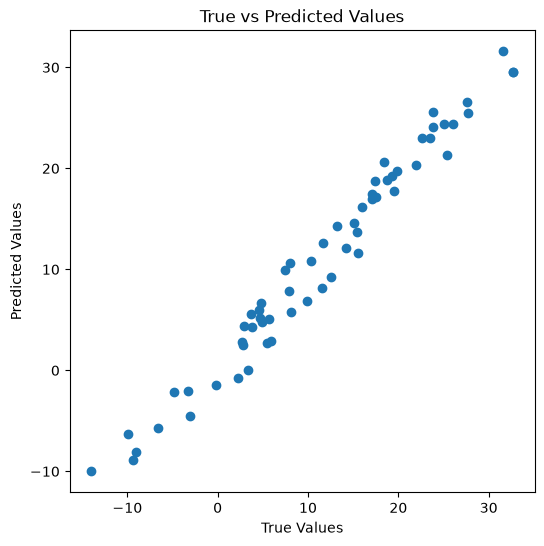

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.show()